## Fraud Detection Problem

The mobile money operator processes large volumes of digital transactions but faces challenges
associated with fraudulent activities such as unauthorized transfers and suspicious transactions.
The objective is to develop a big data analytics solution that learns patterns from historical
transactions and automatically classifies transactions as fraudulent or legitimate.

### Target Variable

- **isFraud**: Binary target variable indicating whether a transaction is fraudulent (1) or legitimate (0).

### Unit of Analysis

- The unit of analysis is an individual mobile money transaction.

### Main Predictors

The main predictors include:
- Transaction step (time)
- Transaction type
- Transaction amount
- Sender and receiver account information
- Old and new account balances

### Business Value

The proposed solution helps the organization:
- Detect fraudulent transactions early.
- Reduce financial losses.
- Improve customer trust and transaction security.
- Support automated fraud monitoring and risk management.

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [23]:
df = pd.read_csv('synthetic_mobile_money_transaction_dataset.csv')
df.head()

,step,transactionType,amount,initiator,oldBalInitiator,newBalInitiator,recipient,oldBalRecipient,newBalRecipient,isFraud
0,0,TRANSFER,19824.96,4537027967639631,187712.18,167887.22,4875702729424478,8.31,19833.27,1
1,0,PAYMENT,598.97,4296267625767470,8.92,8.92,25-0000401,0.00,0.00,0
2,0,PAYMENT,545.85,4178224023847746,93.60,-452.25,13-0001587,0.00,545.85,0
3,0,TRANSFER,19847.01,4178224023847746,-452.25,-20299.26,4096920916696293,4011.72,23858.74,1
4,0,PAYMENT,546.89,4779013371563747,159148.76,158601.88,75-0003564,0.00,546.89,0


### Dataset structure

In [24]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 1720181
Columns: 10


The dataset contains 1720181 rows and 10 columns, representing the total number of transactions and variables respectively.

### Data types

In [19]:
print("\ndata Types")
print(df.dtypes)


data Types
step                          int64
transactionType              object
amount                      float64
initiator                     int64
oldBalInitiator             float64
newBalInitiator             float64
recipient                    object
oldBalRecipient             float64
newBalRecipient             float64
isFraud                       int64
initiator_balance_change    float64
recipient_balance_change    float64
balance_difference          float64
dtype: object


The dataset contains both numerical and categorical variables. Variables such as amount, account balances, and step are numerical and suitable for statistical analysis. transactionType and recipient are categorical variables, while initiator is an identifier and should not be treated as a numeric measurement. The isFraud variable is the target label, indicating whether a transaction is fraudulent or legitimate.

### missing values

In [20]:
print("\nMissing Values")
print(df.isnull().sum())


Missing Values
step                        0
transactionType             0
amount                      0
initiator                   0
oldBalInitiator             0
newBalInitiator             0
recipient                   0
oldBalRecipient             0
newBalRecipient             0
isFraud                     0
initiator_balance_change    0
recipient_balance_change    0
balance_difference          0
dtype: int64


### Duplicate records

In [25]:
print("\nDuplicate Records:", df.duplicated().sum())


Duplicate Records: 0


No duplicate rows were found in the dataset. This indicates that each transaction record is unique, reducing the risk of biased analysis or distorted summary statistics caused by repeated observations.

###  Invalid balances

In [11]:
# Negative balances
balance_columns = [
    'oldBalInitiator',
    'newBalInitiator',
    'oldBalRecipient',
    'newBalRecipient'
]

print("\nNegative Balance Records")
print((df[balance_columns] < 0).sum())



Negative Balance Records
oldBalInitiator    44402
newBalInitiator    44621
oldBalRecipient      117
newBalRecipient       15
dtype: int64


Negative values were found in balance variables, especially in oldBalInitiator and newBalInitiator, with few cases in recipient balances. This may indicate overdrafts or data quality issues and should be considered in further analysis.

### Zero transaction amounts & Very small transactions

In [26]:
# Zero transaction amounts
zero_amounts = (df['amount'] == 0).sum()

# Very small transactions (< 1 unit)
x_small_amounts = (df['amount'] < 1).sum()

print("Zero amounts:", zero_amounts)
print("Amounts less than 1:", x_small_amounts)

Zero amounts: 0
Amounts less than 1: 4


No zero-value transactions were found, and only a few (4) transactions had amounts less than 1. These are rare and may represent unusual or low-value transactions that should be noted in the analysis.

### Extreme transaction amounts

In [27]:
# Using the IQR method
Q1 = df['amount'].quantile(0.25)
Q3 = df['amount'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR

large_transactions = df[df['amount'] > upper_bound]
print("Number of unusually large transactions:", len(large_transactions))

Number of unusually large transactions: 155736


A total of 155,736 transactions were identified as unusually large using the IQR method. This indicates a significant presence of high-value outliers, suggesting that the transaction amount distribution is highly skewed and should be considered in further analysis.

### Class imbalance

In [29]:

print("\nFraud Distribution")
print(df['isFraud'].value_counts())
print("\nFraud Percentage")
print(df['isFraud'].value_counts(normalize=True)*100)


Fraud Distribution
isFraud
0    1544663
1     175518
Name: count, dtype: int64

Fraud Percentage
isFraud
0    89.796539
1    10.203461
Name: proportion, dtype: float64


## Exploratory Data Analysis (EDA) - Visual

### Transaction type frequencies

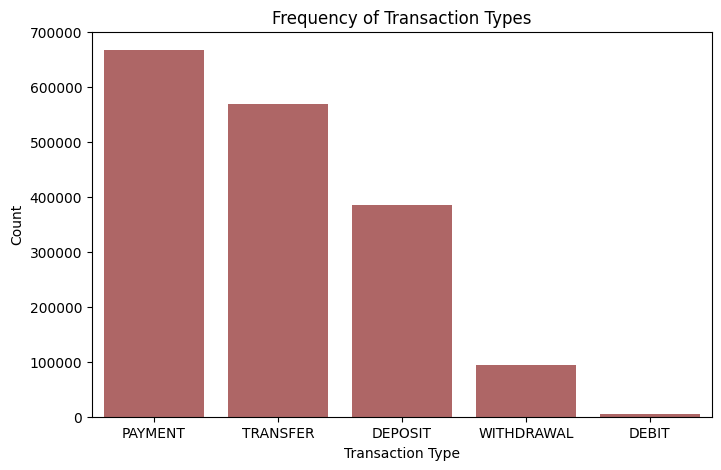

In [33]:
# Bar chart of transaction type frequencies
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='transactionType',
    order=df['transactionType'].value_counts().index,
    color='#BA5A5A'
)

plt.title('Frequency of Transaction Types')
plt.xlabel('Transaction Type')
plt.ylabel('Count')

plt.show()

The distribution of transaction types is highly uneven. Payments and Transfers dominate, accounting for the majority of activity, followed by Deposits. Withdrawals are much less common, and Debits are rare. This shows that users mainly rely on the system for sending money and making payments, while cashing out is less frequent.

### Fraud distribution

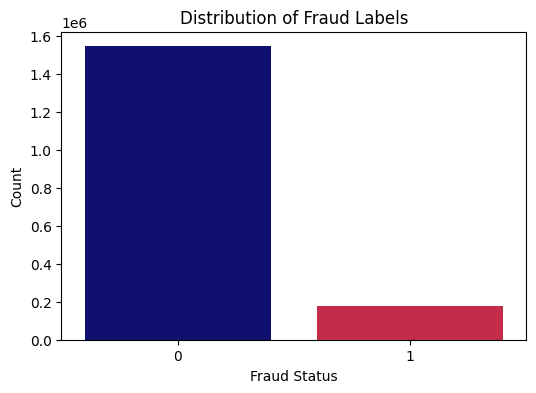

In [35]:
#a bar chart showing the distribution of isFraud;
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x='isFraud',
    hue='isFraud',
    palette=['navy', 'crimson'],
    legend=False
)
plt.title('Distribution of Fraud Labels')
plt.xlabel('Fraud Status')
plt.ylabel('Count')

plt.show()

The dataset exhibits a strong class imbalance, with non-fraudulent transactions greatly outnumbering fraudulent transactions. This imbalance is common in fraud detection datasets and may affect model performance.

### Amount Distribution

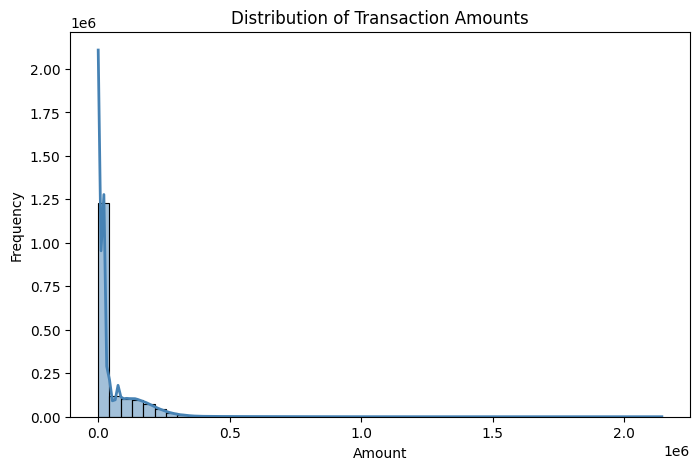

In [38]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['amount'],
    bins=50,
    kde=True,
color='steelblue',
line_kws={'color': 'darkorange', 'linewidth': 2}
)

plt.title("Distribution of Transaction Amounts")
plt.xlabel("Amount")
plt.ylabel("Frequency")

plt.show()

The transaction amount distribution is highly right-skewed. Most transactions are for relatively small amounts, as shown by the large concentration of values near zero. However, there are a few very large transactions that create a long tail extending to the right side of the distribution.

**Summary**

- The data is not normally distributed.
- There are significant outliers (very high transaction amounts).
- The majority of transactions occur at lower amounts, while only a small number involve large amounts.
- The extreme values compress the histogram, making it difficult to see the detailed distribution of smaller transactions.

### Fraud Rate by Transaction Type

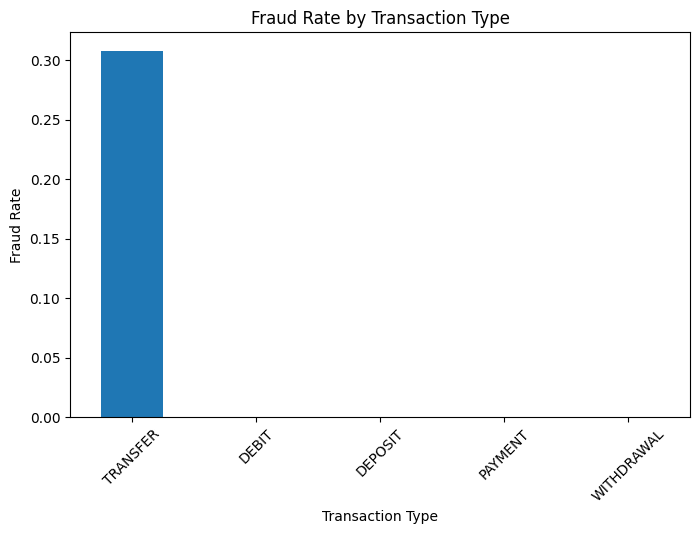

In [41]:
fraud_rate_type = (
    df.groupby('transactionType')['isFraud']
    .mean()
    .sort_values(ascending=False)
)


plt.figure(figsize=(8,5))

fraud_rate_type.plot(
    kind='bar'
)

plt.title("Fraud Rate by Transaction Type")

plt.xlabel("Transaction Type")
plt.ylabel("Fraud Rate")

plt.xticks(rotation=45)

plt.show()

#### **Observations:**

- All fraudulent transactions occur in the TRANSFER category.
- About 31% out of every 100 TRANSFER transactions are fraudulent.
- No fraud cases were observed in DEBIT, DEPOSIT, PAYMENT, or WITHDRAWAL transactions.
- This indicates that transaction type is a highly predictive feature for fraud detection in this dataset

### Fraud Trend Over Time

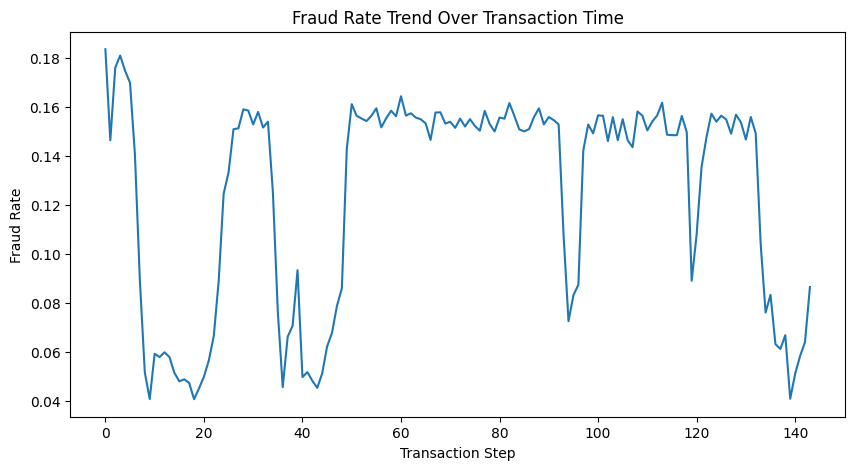

In [42]:
fraud_over_time = (
    df.groupby('step')['isFraud']
    .mean()
)


plt.figure(figsize=(10,5))

fraud_over_time.plot()

plt.title("Fraud Rate Trend Over Transaction Time")
plt.xlabel("Transaction Step")
plt.ylabel("Fraud Rate")

plt.show()

#### **Observations:**

- The fraud rate changes a lot over time. It goes up and down in big waves.
- At the start, fraud is very high — almost 18%.
- It then drops quickly, but keeps coming back in high periods (around 15–16%) and low periods (around 4–6%).
- There are several long waves where fraud stays high for many time steps, then suddenly drops.
- Towards the end, it goes down again but has a small rise at the very end.

### Relationship Between Transaction Amount and Initiator Balance

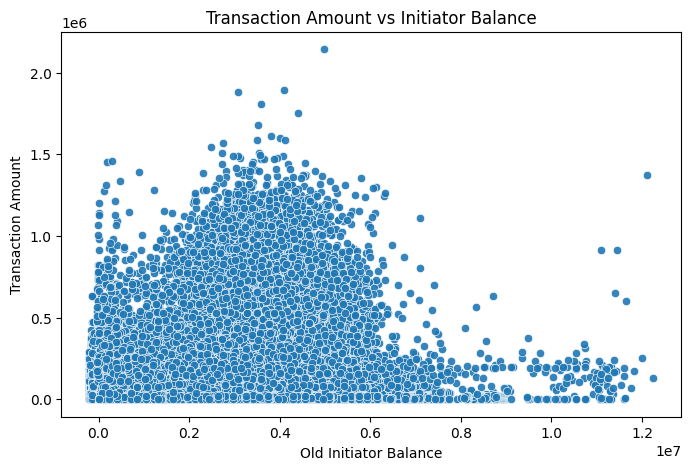

In [49]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    x='oldBalInitiator',
    y='amount',
    data=df,
    alpha=0.9
)

plt.title("Transaction Amount vs Initiator Balance")
plt.xlabel("Old Initiator Balance")
plt.ylabel("Transaction Amount")

plt.show()

#### **Observations:**
- There is a dense cluster of transactions on the left side (low account balances).
- Most large transactions (above 1 million) happen when the old balance is between 2 million to 6 million.
- As the old balance gets higher (especially above 7–8 million), the transaction amounts become mostly small.
- The points form a sort of triangular shape bigger transactions are more common with medium balances, while very high balance accounts tend to do smaller transfers.
- There are some outliers: a few very large transfers even at lower balances.

### Relationship between amount and recipient balances

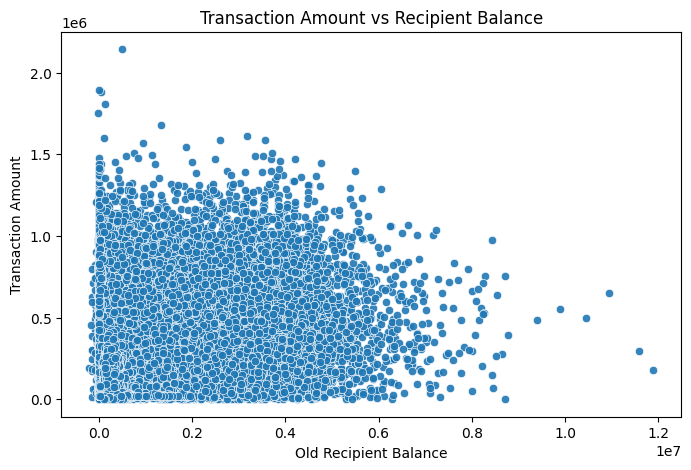

In [50]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    x='oldBalRecipient',
    y='amount',
    data=df,
    alpha=0.9
)

plt.title("Transaction Amount vs Recipient Balance")
plt.xlabel("Old Recipient Balance")
plt.ylabel("Transaction Amount")

plt.show()

#### **Observations:**

- Most transactions are concentrated on the left side when the recipient has a low or zero balance.
- Large transactions (above 1 million) mostly happen when the recipient’s old balance is low to medium (under 4–5 million).
- As the recipient’s old balance gets higher, the transaction amounts tend to be smaller.
- There is a dense cloud of points at lower balances, and the pattern spreads out more as balances increase.

## Feature Engineering for Fraud Detection

#### 1. Transaction-Based Features
   
Transaction Amount Features

Fraudulent transactions often involve unusually large or abnormal transaction amounts.

log_amount=log(1+amount)

df['log_amount'] = np.log1p(df['amount'])

In [51]:
df['log_amount'] = np.log1p(df['amount'])

In [52]:
np.log(1 + df['amount'])

0           9.894747
1           6.396880
2           6.304175
3           9.895859
4           6.306075
             ...    
1720176    12.149513
1720177     6.553648
1720178    11.336197
1720179     6.398229
1720180     9.752188
Name: amount, Length: 1720181, dtype: float64

#### Balance Change Features
Measures how much money leaves the sender account.

initiator_balance_change=oldBalInitiator−newBalInitiator

In [53]:
df['initiator_balance_change'] = (
    df['oldBalInitiator'] -
    df['newBalInitiator']
)

#### Recipient Balance Change

Measures money received by the recipient.

recipient_balance_change=newBalRecipient−oldBalRecipient

In [54]:
df['recipient_balance_change'] = (
    df['newBalRecipient'] -
    df['oldBalRecipient']
)

#### Balance Consistency Features
Fraudulent transactions may contain inconsistencies between transaction amounts and account balance changes.

Initiator Balance Error
balance_error=amount−(oldBalInitiator−newBalInitiator)

In [55]:
df['initiator_balance_error'] = (
    df['amount'] -
    df['initiator_balance_change']
)

#### Account Balance Ratio Features
Measures whether a transaction is large compared with available funds.

transaction_ratio=
oldBalInitiator+1
amount


In [56]:
df['transaction_balance_ratio'] = (
    df['amount'] /
    (df['oldBalInitiator'] + 1)
)

#### Transaction Type Encoding

transactionType is categorical and must be converted into numerical format before modelling.

In [57]:
df = pd.get_dummies(
    df,
    columns=['transactionType'],
    drop_first=True
)

#### Time-Based Features

The variable step represents transaction sequence/time.

Additional temporal features can be created:

Transaction hour
Day period
Time interval

In [58]:
df['transaction_hour'] = df['step'] % 24

### Account Behaviour Features

In [59]:
df['initiator_frequency'] = (
    df.groupby('initiator')['initiator']
    .transform('count')
)

In [60]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1720181 entries, 0 to 1720180
Data columns (total 20 columns):
 #   Column                      Dtype  
---  ------                      -----  
 0   step                        int64  
 1   amount                      float64
 2   initiator                   int64  
 3   oldBalInitiator             float64
 4   newBalInitiator             float64
 5   recipient                   object 
 6   oldBalRecipient             float64
 7   newBalRecipient             float64
 8   isFraud                     int64  
 9   log_amount                  float64
 10  initiator_balance_change    float64
 11  recipient_balance_change    float64
 12  initiator_balance_error     float64
 13  transaction_balance_ratio   float64
 14  transactionType_DEPOSIT     bool   
 15  transactionType_PAYMENT     bool   
 16  transactionType_TRANSFER    bool   
 17  transactionType_WITHDRAWAL  bool   
 18  transaction_hour            int64  
 19  initiator_frequency  

In [62]:
y = df['isFraud']

In [64]:
X = df.drop('isFraud', axis=1)

In [65]:
print("Features:", X.shape)
print("Target:", y.shape)

Features: (1720181, 19)
Target: (1720181,)


### Encode Categorical Variables

In [66]:
X = df.drop(
    ['isFraud', 'initiator', 'recipient'],
    axis=1
)

In [67]:
X = df.drop(
    ['isFraud', 'initiator', 'recipient'],
    axis=1
)

## Train-Test Data Split

In [68]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [69]:
X_train.shape
y_train.value_counts()

isFraud
0    1235730
1     140414
Name: count, dtype: int64

Class Weighting (class_weight='balanced')

#### Logistic Regression

In [71]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)

lr_model.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

#### Random Forest

In [72]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_jobs=-1, random_state=42)

#### Decision

In [86]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    class_weight='balanced',
    random_state=42,
    max_depth=10
)

dt_model.fit(
    X_train,
    y_train
)

DecisionTreeClassifier(class_weight='balanced', max_depth=10, random_state=42)

In [87]:
y_pred_dt = dt_model.predict(X_test)

y_prob_dt = dt_model.predict_proba(X_test)[:,1]

In [81]:
from xgboost import XGBClassifier
fraud_ratio = (
    y_train.value_counts()[0] /
    y_train.value_counts()[1]
)

fraud_ratio

8.800618171977153

In [88]:
from xgboost import XGBClassifier

# Calculate class imbalance ratio
fraud_ratio = (
    y_train.value_counts()[0] /
    y_train.value_counts()[1]
)

xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    scale_pos_weight=fraud_ratio,
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(
    X_train,
    y_train
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

In [89]:
y_pred_xgb = xgb_model.predict(X_test)

y_prob_xgb = xgb_model.predict_proba(X_test)[:,1]

In [90]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# Collect model predictions
models = {
    "Logistic Regression": (y_pred_lr, y_prob_lr),
    "Decision Tree": (y_pred_dt, y_prob_dt),
    "Random Forest": (y_pred_rf, y_prob_rf),
    "XGBoost": (y_pred_xgb, y_prob_xgb)
}


# Store results
model_results = []


for model_name, (predictions, probabilities) in models.items():

    model_results.append({
        "Model": model_name,
        "Accuracy": round(
            accuracy_score(y_test, predictions), 4
        ),
        "Precision": round(
            precision_score(y_test, predictions), 4
        ),
        "Recall": round(
            recall_score(y_test, predictions), 4
        ),
        "F1-score": round(
            f1_score(y_test, predictions), 4
        ),
        "ROC-AUC": round(
            roc_auc_score(y_test, probabilities), 4
        )
    })


# Convert to dataframe
results_df = pd.DataFrame(model_results)


# Sort by ROC-AUC
results_df = results_df.sort_values(
    by="ROC-AUC",
    ascending=False
)


# Display results
results_df

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
3,XGBoost,0.7835,0.3202,0.9992,0.4850,0.8897
2,Random Forest,0.9024,0.6549,0.0916,0.1607,0.8894
1,Decision Tree,0.7834,0.3201,0.9990,0.4848,0.8892
0,Logistic Regression,0.7235,0.2462,0.8295,0.3797,0.8156


## Model Performance Comparison and Interpretation

The four supervised machine learning models were evaluated using accuracy, precision, recall, F1-score, and ROC-AUC. Due to the highly imbalanced nature of fraud detection data, recall and F1-score were given greater consideration because the main objective is to identify fraudulent transactions.

The results showed different performance characteristics across the models.

XGBoost achieved the highest recall (99.92%) and the highest F1-score (0.4850), indicating that it successfully detected almost all fraudulent transactions. However, its lower precision (32.02%) suggests that it generated a relatively high number of false positive fraud alerts.

Decision Tree produced similar performance to XGBoost, achieving a recall of 99.90% and F1-score of 0.4848. However, its slightly lower ROC-AUC indicates weaker overall discrimination compared with XGBoost.

Random Forest achieved the highest accuracy (90.24%) and precision (65.49%). However, its recall was only 9.16%, meaning that it failed to detect most fraudulent transactions. This makes it less suitable for fraud detection despite its strong overall accuracy.

Logistic Regression provided a baseline model with moderate fraud detection capability, achieving a recall of 82.95% and ROC-AUC of 81.56%.

Considering the business objective of minimizing missed fraudulent transactions, XGBoost was selected as the preferred model because it achieved the highest fraud detection capability while maintaining strong overall classification performance.

In [92]:
import pandas as pd

importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model.feature_importances_
})


importance = importance.sort_values(
    by='Importance',
    ascending=False
)

importance.head(10)

,Feature,Importance
13,transactionType_TRANSFER,0.202404
8,recipient_balance_change,0.130169
7,initiator_balance_change,0.088266
1,amount,0.084178
6,log_amount,0.080990
10,transaction_balance_ratio,0.051542
3,newBalInitiator,0.050768
16,initiator_frequency,0.047448
2,oldBalInitiator,0.046534
5,newBalRecipient,0.037850


| Predictor                     | Importance | Interpretation                                                                                                                                                       |
| ----------------------------- | ---------: | -------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **transactionType_TRANSFER**  |     0.2024 | This was the most important predictor, indicating that transfer transactions are more likely to be associated with fraudulent activity than other transaction types. |
| **recipient_balance_change**  |     0.1302 | Large or unusual changes in the recipient's account balance are strong indicators of potential fraud.                                                                |
| **initiator_balance_change**  |     0.0883 | Significant reductions in the sender's balance following a transaction provide useful information for identifying suspicious transactions.                           |
| **amount**                    |     0.0842 | Higher transaction amounts are more likely to be associated with fraudulent behaviour, making transaction value an important predictor.                              |
| **log_amount**                |     0.0810 | The log-transformed transaction amount reduces skewness while preserving information about transaction size, improving the model's ability to detect fraud.          |
| **transaction_balance_ratio** |     0.0515 | Transactions that consume a large proportion of the sender's available balance are more likely to be suspicious.                                                     |
| **newBalInitiator**           |     0.0508 | The remaining balance after a transaction provides additional information about whether the transaction is financially consistent.                                   |
| **initiator_frequency**       |     0.0474 | Accounts performing transactions more frequently may exhibit behavioural patterns associated with fraudulent activities.                                             |


#### Discussion

The results show that transaction type, particularly TRANSFER, is the strongest predictor of fraud. This suggests that fraudsters preferentially use transfer transactions to move funds between accounts. Features describing balance changes for both the sender and recipient were also highly influential, indicating that abnormal money movement is a key characteristic of fraudulent transactions.

Furthermore, transaction amount and the transaction-to-balance ratio demonstrate that unusually large transactions or transactions representing a substantial proportion of the sender's available balance are more likely to be fraudulent. The inclusion of initiator frequency also highlights the importance of customer behavioural patterns, suggesting that unusually active accounts may require closer monitoring.

Overall, these findings indicate that combining transaction characteristics, balance information, and behavioural features enables machine learning models to effectively distinguish fraudulent transactions from legitimate ones.

In [77]:
import joblib

# Save Logistic Regression model
joblib.dump(
    lr_model,
    "logistic_regression_fraud_model.pkl"
)

# Save Random Forest model
joblib.dump(
    rf_model,
    "random_forest_fraud_model.pkl"
)

print("Models saved successfully")

Models saved successfully
